# ***VGG16***

# Stage 1 - Preparation

## **Step 1.1: Configuration(Reproducibility)**
 - The goal: to fix randomness for Python, Numpy, and TensorFlow so that when training is restarted, the results are as stable as possible.

In [ ]:
import tensorflow as tf
import numpy as np
import random
import os

## **Step 1.2: Checking the GPU**
 - The goal: Make sure that the training will take place on the GPU (speeds up the training several times).

In [ ]:
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **Step 1.3: Fixing the Random Seed**
 - Goal: Ensure reproducibility of the experiment

In [ ]:
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Stage 2 - Preparing and uploading data



## **Connecting Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Checking the folder path

!ls "/content/drive/MyDrive/banana_dataset"

dataset


In [ ]:
# Checking the content

!ls "/content/drive/MyDrive/banana_dataset/dataset"

test  train  val


In [ ]:
!ls "/content/drive/MyDrive/banana_dataset/dataset/train"

overripe  ripe	unripe


## **Step 2.1: Loading data(train / val / test)**
 - The goal:
   - count images
   - automatically assign class labels
   - bring it to a size of 224×224(preprocessing)
   - form a batch

A batch is a small group of images
that the model processes in one training step:
1) not to download all the data at once
2) in order to save GPU memory
3) the training is stable

In [ ]:
train_dir = "/content/drive/MyDrive/banana_dataset/dataset/train"
val_dir = "/content/drive/MyDrive/banana_dataset/dataset/val"
test_dir = "/content/drive/MyDrive/banana_dataset/dataset/test"

print("------------------ TRAIN: ------------------")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,   # path to /train
    image_size=(224, 224),     # size for VGG-16
    batch_size=32,             # batch size
    shuffle=True,              # mixing the train(so that the model doesn't learn from the order of the images)
    seed=SEED                  # using a fixed seed
)


print("------------------ VALIDATION: ------------------")

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False              # /val do not mix
)


print("----------------- TEST: ------------------")

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False              # /test do not mix
)

------------------ TRAIN: ------------------
Found 6736 files belonging to 3 classes.
------------------ VALIDATION: ------------------
Found 1825 files belonging to 3 classes.
----------------- TEST: ------------------
Found 1401 files belonging to 3 classes.


In [ ]:
print(train_dataset.class_names)

['overripe', 'ripe', 'unripe']


## **Step 2.2: Checking the number of images by class**
 - Goal:
   - make sure that the data is distributed correctly
   - check if there is an imbalance
   - understand how many examples there are in each class
   - evaluate whether there is enough data for training

In [ ]:
import os     # library for working with folders and files

In [ ]:
def count_images(directory):     # a function for counting images in each class folder
    counts = {}                  # storing the result as a dictionary: {'unripe': 620, ...}

    for class_name in os.listdir(directory):               # going through each object inside the folder (  overripe, ripe, unripe,)
        class_path = os.path.join(directory, class_name)   # creating the full path to the class folder

        if os.path.isdir(class_path):                # checking that this is actually a folder and not a file
            counts[class_name] = len(os.listdir(class_path))    # counting the number of files (images) in the class folder

    return counts       # returning the dictionary with the number of images

print("TRAIN SET:", count_images(train_dir))

print("VALIDATION SET:", count_images(val_dir))
print("TEST SET:", count_images(test_dir))

TRAIN SET: {'overripe': 4301, 'ripe': 1815, 'unripe': 620}
VALIDATION SET: {'overripe': 1326, 'ripe': 315, 'unripe': 184}
TEST SET: {'overripe': 1010, 'ripe': 211, 'unripe': 180}


In [ ]:
# visualization by a table

import pandas as pd   # library for tables

train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

df = pd.DataFrame({
    "Class": ["overripe", "ripe", "unripe"],
    "Train count": [train_counts.get("overripe", 0),
                    train_counts.get("ripe", 0),
                    train_counts.get("unripe", 0)],
    "Validation Count": [val_counts.get("overripe", 0),
                         val_counts.get("ripe", 0),
                         val_counts.get("unripe", 0)],
    "Test Count": [test_counts.get("overripe", 0),
                   test_counts.get("ripe", 0),
                   test_counts.get("unripe", 0)]
})

df

,Class,Train count,Validation Count,Test Count
0,overripe,4301,1326,1010
1,ripe,1815,315,211
2,unripe,620,184,180


## **Step 2.3: Balancing Classes**
 - Goal: Compensate for the class imbalance in the **train** sample
so that the model does not shift towards the **OVERRIPE** class.

 Without balancing, the model will more often predict the dominant class.


### **Step 2.3.1: Extracting labels from train**
To find:
 - how many examples are there in each class
 - calculate the correct class_weights

In [ ]:
train_labels = []   # empty list for saving labels

for images, labels in train_dataset:   #  go through all the train batches(images, labels: classes 0, 1, 2)
    train_labels.extend(labels.numpy())  # adding labels to the list

train_labels = np.array(train_labels)  # converting the list to a NumPy array

print(train_labels)

[1 1 1 ... 2 0 2]


### **Step 2.3.2: Calculating class weights**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_labels)  # getting unique classes

class_weights_values = compute_class_weight(
    class_weight='balanced',   # using automatic balancing
    classes=classes,
    y=train_labels
)

class_weights = dict(zip(classes, class_weights_values))  # converting it to a dictionary

class_weights = {int(k): float(v) for k, v in class_weights.items()}
print(class_weights)

{0: 0.5220491358598776, 1: 1.2370982552800736, 2: 3.621505376344086}


## **Step 2.4: Preprocessing (Resize + Normalization)**
 - Goal: Import a special normalization function for VGG16,
which was used during training on ImageNet

### **Step 2.4.1: Importing the normalization function**

ResNet50 was trained on ImageNet, where:

 - pixels WEREN'T just divisible by 255

 - the special function **preprocess_input** was used
 - performed:
   - RGB → BGR conversion
   - subtracting ImageNet **averages**

Therefore, we use:

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input  # special normalization for VGG16

### **Step 2.4.2: Applying Normalization to a Dataset**
 - .map() - allows to change the data inside the dataset
 - lambda x, y:
   - x - images
   - y - labels

In [ ]:
train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

In [ ]:
# accelerates learning
# optimizes data loading
# prevents bottleneck when reading images

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Stage 3 - Architecture

## **Step 3.1: Augmentation (for train only)**
 - Goal: Increase the variety of training data:
    - see the bananas from different angles
    - become more resistant to lighting
    - retraining will decrease

In [ ]:
from tensorflow.keras import layers

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),  # random reflection
    layers.RandomRotation(0.1),       # small turn to 10%
    layers.RandomZoom(0.1),           # small increase
    layers.RandomBrightness(0.2),     # changing brightness(resistance to light)
    layers.RandomContrast(0.2),       # changing the contrast(resistance to camera quality)
])

## **Step 3.2: Base Model (VGG16)**
 - Goal: Download the pre-trained VGG16 (ImageNet) model
as a powerful feature extractor

In [ ]:
from tensorflow.keras.applications import VGG16  # importing a pre-trained model

In [ ]:
base_model = VGG16(
    weights='imagenet',      # using pre-trained ImageNet weights
    include_top=False,       # removing the original classifier (Dense layer - 1000 classes ImageNet), bc i have 3 classes: or, r, ur
    input_shape=(224, 224, 3)  # the size of the input images (3 -> RGB)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## **Step 3.3: Head(model's head)**
 - Goal: Adapt VGG16 to my task:
   - instead of 1000 ImageNet classes make a classification into **3 classes**: overripe, ripe, unripe
   - add **regularization** (protection against **overfitting**)
   - prepare the model for Stage 1 (Frozen)

In [ ]:
from tensorflow.keras.regularizers import l2 #importing L2 regularization to protect the model from overfitting

In [ ]:
model = tf.keras.Sequential([
    data_augmentation,                     # augmentation
    base_model,                            # VGG16 feature extractor
    layers.GlobalAveragePooling2D(),       # reduce feature maps
    layers.Dropout(0.5),                   # stronger dropout (VGG16 is heavier(has more parameters), deeper, VGG16 is prone to overfitting on a small dataset)
    layers.Dense(
        3,
        activation='softmax',
        kernel_regularizer=l2(0.01)        # L2 regularization (important!)
    )
])

# Stage 4 — Training Stage-1

## **Step 4: Stage 1 - Frozen Base**
 - Goal: Train only the classification part (Head),
leaving ResNet50 frozen. It allows to:
   - save pre-trained features
   - adapt the model to 3 classes
   - avoid destroying ImageNet scales


### **Step 4.1: Base Freezing (Stage 1)**
 - why?: At the first stage:
   - only train our "head"
   - don't touch the already trained filters
   - preventing the destruction of ImageNet scales

In [ ]:
base_model.trainable = False  # freezing all VGG16 layers

## **Step 4.2: Stage 1 - Checking the number of parameters to be trained**
 - Goal: Show how many parameters are actually being trained

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## **Step 4.3: Stage 1 - Compilation of the model**
 - Goal: Identify: the loss function, the optimizer, metrics

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # Adam optimizer
    loss='sparse_categorical_crossentropy',  # loss function
    metrics=['accuracy']  # accuracy metric
)

## **Step 4.3: Stage 1 - EarlyStopping**
 - Goal:
   - prevents overfitting
   - stops learning automatically
   - saves the best model

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',        # monitoring the error during validation
    patience=5,                # waiting for 5 epochs without improvement
    restore_best_weights=True  # return the best weights
)

## **Step 4.4: Stage 1 - Start training**
 - Goal: Train only the classification part of the model
with a frozen VGG16 database

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    class_weight=class_weights,  # balancing
    callbacks=[early_stop]
)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 536s 2s/step - accuracy: 0.5732 - loss: 1.1475 - val_accuracy: 0.3156 - val_loss: 3.3644
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 39s 184ms/step - accuracy: 0.7306 - loss: 0.6388 - val_accuracy: 0.4625 - val_loss: 2.2182
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 37s 174ms/step - accuracy: 0.7818 - loss: 0.5241 - val_accuracy: 0.4975 - val_loss: 1.9819
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 38s 179ms/step - accuracy: 0.7985 - loss: 0.4866 - val_accuracy: 0.4553 - val_loss: 2.1805
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 37s 177ms/step - accuracy: 0.8042 - loss: 0.4872 - val_accuracy: 0.5178 - val_loss: 1.7558
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 37s 178ms/step - accuracy: 0.8085 - loss: 0.4623 - val_accuracy: 0.4515 - val_loss: 2.1087
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 38s 179ms/step - accuracy: 0.8124 - loss: 0.4602 - val_accuracy: 0.5337 - val_loss: 1.7555
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 38s 179ms/step - accuracy: 0.8116 - loss: 0.4

In [ ]:
val_accuracies = history.history['val_accuracy']

best_epoch_acc = np.argmax(val_accuracies) + 1

print("Best epoch (by val_accuracy):", best_epoch_acc)
print("Best val_accuracy:", val_accuracies[best_epoch_acc - 1])
print("Val_loss at that epoch:", history.history['val_loss'][best_epoch_acc - 1])

Best epoch (by val_accuracy): 16
Best val_accuracy: 0.6284931302070618
Val_loss at that epoch: 1.3166569471359253


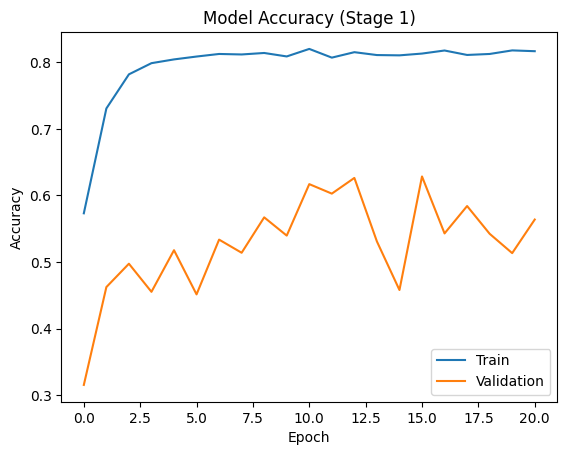

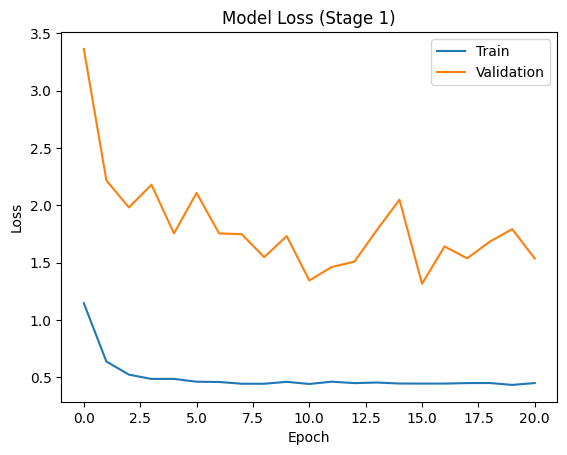

In [ ]:
import matplotlib.pyplot as plt  # import for charts

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy (Stage 1)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss (Stage 1)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Stage 5 — Training Stage 2

## **Step 5: Stage 2 - Partial Fine-Tuning**
 - Goal: Unfreeze only the last block of VGG16:
   - adapt deep filters to the texture of the peel
   - improve spot recognition
   - improve accuracy

But at the same time:
do not destroy low-level features (edges, shapes)

## **Step 5.1: Stage 2 - Unfreeze ONLY the last layer (20 layers)**
 - Goal: Allow training of only one last layer VGG16

In [ ]:
base_model.trainable = False # first we freeze everything

In [ ]:
# then defrost only the last layer

# for layer in base_model.layers:
#     if layer.name == "block5_conv3":
for layer in base_model.layers[-20:]:
        layer.trainable = True

## **Step 5.1.1: Stage 2 - Checking trainable parameters**

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,307 (56.15 MB)

 Trainable params: 14,716,227 (56.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,080 (12.04 KB)

## **Step 5.2: Stage 2 - !Decreasing Learning Rate**
 - Why 1e-4?
   - now the pre-trained weights are being changed
   - the learning step should be more careful
   - otherwise, destroy useful signs

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # less learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 5.3: Stage 2 - Training**

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 119s 508ms/step - accuracy: 0.7821 - loss: 0.5730 - val_accuracy: 0.6762 - val_loss: 1.1986
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 484ms/step - accuracy: 0.8686 - loss: 0.3484 - val_accuracy: 0.2729 - val_loss: 3.3566
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 482ms/step - accuracy: 0.8379 - loss: 0.3740 - val_accuracy: 0.6104 - val_loss: 1.5072
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 482ms/step - accuracy: 0.8887 - loss: 0.2662 - val_accuracy: 0.5715 - val_loss: 2.4998
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 483ms/step - accuracy: 0.8999 - loss: 0.2483 - val_accuracy: 0.4104 - val_loss: 2.9815
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 483ms/step - accuracy: 0.9148 - loss: 0.2132 - val_accuracy: 0.4016 - val_loss: 2.0491


In [ ]:
val_accuracies = history_stage2.history['val_accuracy']

best_epoch_acc = np.argmax(val_accuracies) + 1

print("Stage 2:")
print("Best epoch (by val_accuracy):", best_epoch_acc)
print("Best val_accuracy:", val_accuracies[best_epoch_acc - 1])
print("Val_loss at that epoch:", history_stage2.history['val_loss'][best_epoch_acc - 1])

Stage 2:
Best epoch (by val_accuracy): 1
Best val_accuracy: 0.6761643886566162
Val_loss at that epoch: 1.1985900402069092


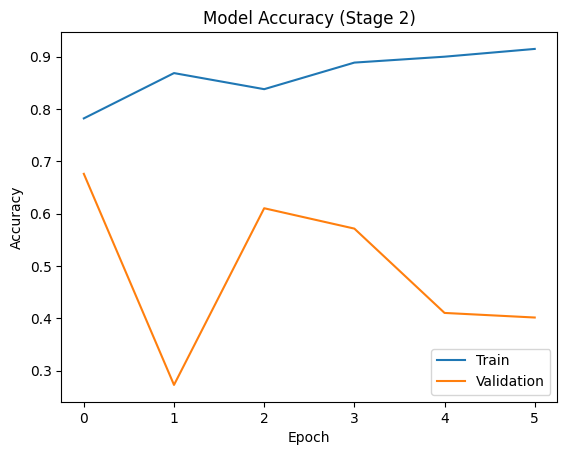

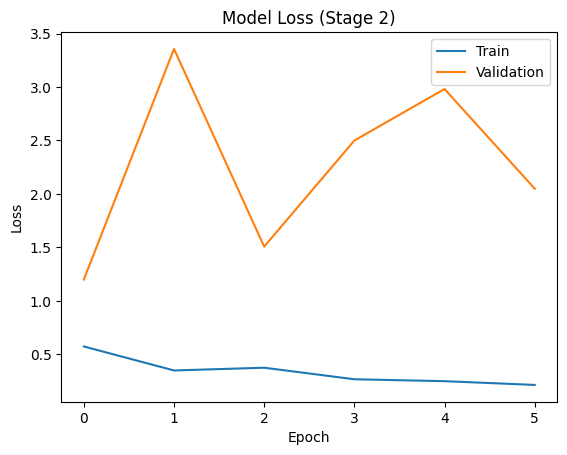

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history_stage2.history['accuracy'])
plt.plot(history_stage2.history['val_accuracy'])
plt.title('Model Accuracy (Stage 2)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history_stage2.history['loss'])
plt.plot(history_stage2.history['val_loss'])
plt.title('Model Loss (Stage 2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

saving model Stage 2:

In [ ]:
model.save("vgg16_stage2.keras")

In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'vgg16_stage2.keras', 'sample_data']


In [ ]:
import os
print(os.path.getsize("vgg16_stage2.keras") / (1024*1024), "MB")

168.53045463562012 MB


In [ ]:
from tensorflow.keras.models import load_model

model_stage2 = load_model("vgg16_stage2.keras")
print("Stage 2 model loaded successfully!")

Stage 2 model loaded successfully!


In [ ]:
model.save("/content/drive/MyDrive/vgg16_stage2.keras")

# Stage 6 - Testing the model(Stage 2)

## **Step 6: Final Testing Stage 2**
 - Goal: Evaluate the quality of the model based on completely new data
that was not used either for training or validation

## **Step 6.1: Loading a saved Stage-2 model**
 - Goal: Restore the Stage 2 model in memory for honest testing

In [ ]:
from tensorflow.keras.models import load_model

model_stage2 = load_model("vgg16_stage2.keras")
print("Stage 2 model loaded successfully!")

Stage 2 model loaded successfully!


## **Step 6.2: Getting predictions(Stage-2)**
 - Goal: Get predicted classes for all test_dataset images

The model's **predictions** are used to compare with **true labels** and calculate quality metrics

In [ ]:
import numpy as np

y_pred_probs = model_stage2.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_dataset], axis=0)

44/44 ━━━━━━━━━━━━━━━━━━━━ 345s 8s/step


## **Step 6.3: Getting TRUE labels(Stage-2)**
 - Goal: Collect real class labels for comparison with predictions

In [ ]:
y_true = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

## **Step 6.4: Classification Report(Stage-2)**
 - Goal: Estimate: precision, recall, F1-score for each class

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['overripe', 'ripe', 'unripe']
))

              precision    recall  f1-score   support

    overripe       1.00      0.54      0.71      1010
        ripe       0.29      0.89      0.44       211
      unripe       0.88      1.00      0.94       180

    accuracy                           0.65      1401
   macro avg       0.72      0.81      0.69      1401
weighted avg       0.88      0.65      0.69      1401



In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy (Stage 2): {:.2f}%".format(accuracy * 100))

Test Accuracy (Stage 2): 65.45%


In [ ]:
from sklearn.metrics import f1_score

macro_f1_stage2 = f1_score(y_true, y_pred, average="macro")
print("Macro F1 (Stage 2): {:.4f}".format(macro_f1_stage2))

Macro F1 (Stage 2): 0.6928


## **Step 6.5: Confusion Matrix(Stage-2)**
- Goal: see which classes the model is confusing

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[550 460   0]
 [  0 187  24]
 [  0   0 180]]


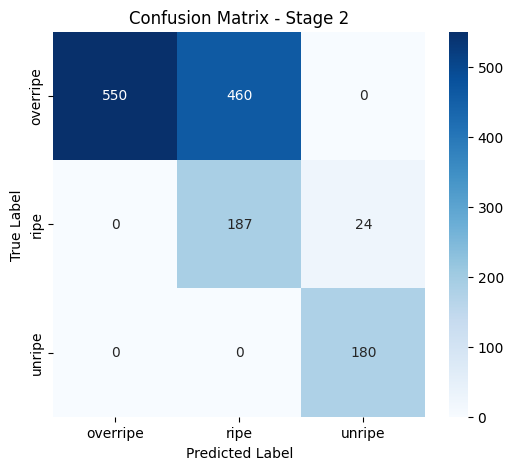

In [ ]:
# Visualize

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# вычисляем матрицу
cm = confusion_matrix(y_true, y_pred)

# строим график
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['overripe', 'ripe', 'unripe'],
            yticklabels=['overripe', 'ripe', 'unripe'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Stage 2")
plt.show()

# Stage 7 — Training Stage 3

## **Step 7: Stage 3 - Full Fine-Tuning**
 - Goal: Unfreeze the entire VGG16 to:
   - fine-tune all filters to match the texture of bananas
   - improve the distinction between similar stages (ripe vs overripe)
   - get maximum accuracy

## **Step 7.1: Stage 3 - Unfreeze all layers**

In [ ]:
base_model.trainable = True  # allow training of all VGG16 layers

## **Step 7.1.1: Stage 2 - Checking trainable parameters**

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,148,683 (168.41 MB)

 Trainable params: 14,716,227 (56.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,432,456 (112.28 MB)

## **Step 7.2: Stage 3 - Decreasing Learning Rate**
very important

 - Why 1e-5?
   - now ALL the pre-trained weights are changed
   - taking too big a step will destroy useful signs
   - need a very careful setup

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # very small step
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 7.3: Stage 3 - Training**

In [ ]:
history_stage3 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 108s 492ms/step - accuracy: 0.9041 - loss: 0.2480 - val_accuracy: 0.8110 - val_loss: 0.6206
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 485ms/step - accuracy: 0.9157 - loss: 0.2151 - val_accuracy: 0.7951 - val_loss: 0.7440
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 484ms/step - accuracy: 0.9252 - loss: 0.1876 - val_accuracy: 0.8526 - val_loss: 0.6072
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 485ms/step - accuracy: 0.9237 - loss: 0.1912 - val_accuracy: 0.8910 - val_loss: 0.3525
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 483ms/step - accuracy: 0.9308 - loss: 0.1759 - val_accuracy: 0.8005 - val_loss: 0.6718
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 484ms/step - accuracy: 0.9347 - loss: 0.1642 - val_accuracy: 0.8181 - val_loss: 0.6642
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 484ms/step - accuracy: 0.9319 - loss: 0.1699 - val_accuracy: 0.8548 - val_loss: 0.4958
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 484ms/step - accuracy: 0.9368 -

In [ ]:
val_accuracies = history_stage3.history['val_accuracy']

best_epoch_acc = np.argmax(val_accuracies) + 1

print("Stage 3:")
print("Best epoch (by val_accuracy):", best_epoch_acc)
print("Best val_accuracy:", val_accuracies[best_epoch_acc - 1])
print("Val_loss at that epoch:", history_stage3.history['val_loss'][best_epoch_acc - 1])

Stage 3:
Best epoch (by val_accuracy): 4
Best val_accuracy: 0.8909589052200317
Val_loss at that epoch: 0.35254156589508057


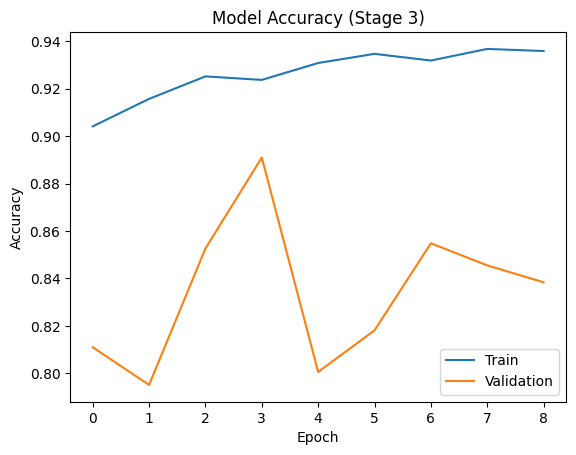

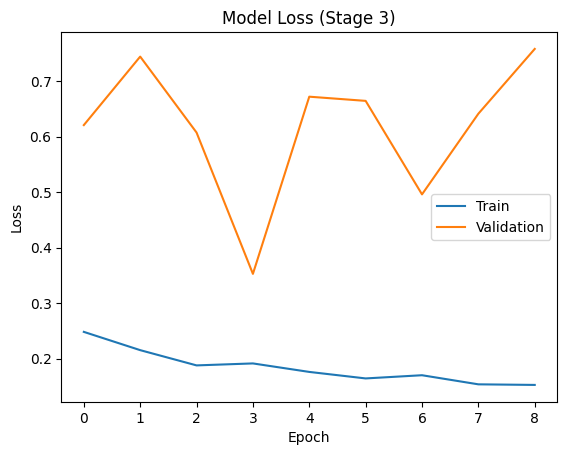

In [ ]:
#visualize

import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history_stage3.history['accuracy'])
plt.plot(history_stage3.history['val_accuracy'])
plt.title('Model Accuracy (Stage 3)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history_stage3.history['loss'])
plt.plot(history_stage3.history['val_loss'])
plt.title('Model Loss (Stage 3)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

saving Stage 3:

In [ ]:
model.save("vgg16_stage3.keras")
print("Stage 3 model saved successfully!")

Stage 3 model saved successfully!


# Stage 8 — Testing Stage 3

## **Step 8.1: Loading a saved Stage 3 model**

In [ ]:
from tensorflow.keras.models import load_model

model_stage3 = load_model("vgg16_stage3.keras")
print("Stage 3 model loaded successfully!")

Stage 3 model loaded successfully!


## **Step 8.2: Getting predictions(Stage 3)**

In [ ]:
import numpy as np

y_pred_probs = model_stage3.predict(test_dataset)
y_pred_stage3 = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_dataset], axis=0)

44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step


## **Step 8.3: Classification Report(Stage 3)**

In [ ]:
print(classification_report(
    y_true,
    y_pred_stage3,
    target_names=['overripe', 'ripe', 'unripe']
))

              precision    recall  f1-score   support

    overripe       1.00      0.85      0.92      1010
        ripe       0.57      0.97      0.72       211
      unripe       0.96      1.00      0.98       180

    accuracy                           0.89      1401
   macro avg       0.85      0.94      0.87      1401
weighted avg       0.93      0.89      0.90      1401



In [ ]:
from sklearn.metrics import accuracy_score

accuracy_stage3 = accuracy_score(y_true, y_pred_stage3)
print("Test Accuracy (Stage 3): {:.2f}%".format(accuracy_stage3 * 100))

Test Accuracy (Stage 3): 88.65%


In [ ]:
from sklearn.metrics import f1_score

macro_f1_stage3 = f1_score(y_true, y_pred_stage3, average='macro')
print("Macro F1-score (Stage 3): {:.2f}".format(macro_f1_stage3))

Macro F1-score (Stage 3): 0.87


## **Step 8.4: Confusion Matrix(Stage 3)**

In [ ]:
from sklearn.metrics import confusion_matrix

cm_stage3 = confusion_matrix(y_true, y_pred_stage3)
print(cm_stage3)

[[858 152   0]
 [  0 204   7]
 [  0   0 180]]


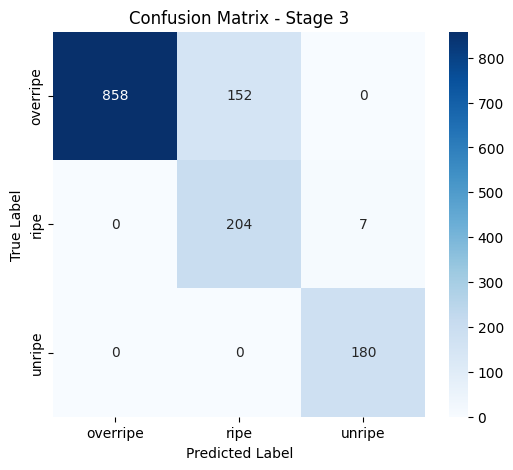

In [ ]:
#visualize

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_stage3,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['overripe', 'ripe', 'unripe'],
    yticklabels=['overripe', 'ripe', 'unripe']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Stage 3")
plt.show()

## **BEST ACCURACY: STAGE-3**